Exploring Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('train.csv')

In [3]:
data.head()
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [ ]:
data['Vehicle_Age']
data['Vehicle_Damage']
data['Annual_Premium']

AttributeError: 'Series' object has no attribute 'value'

<Axes: xlabel='Annual_Premium'>

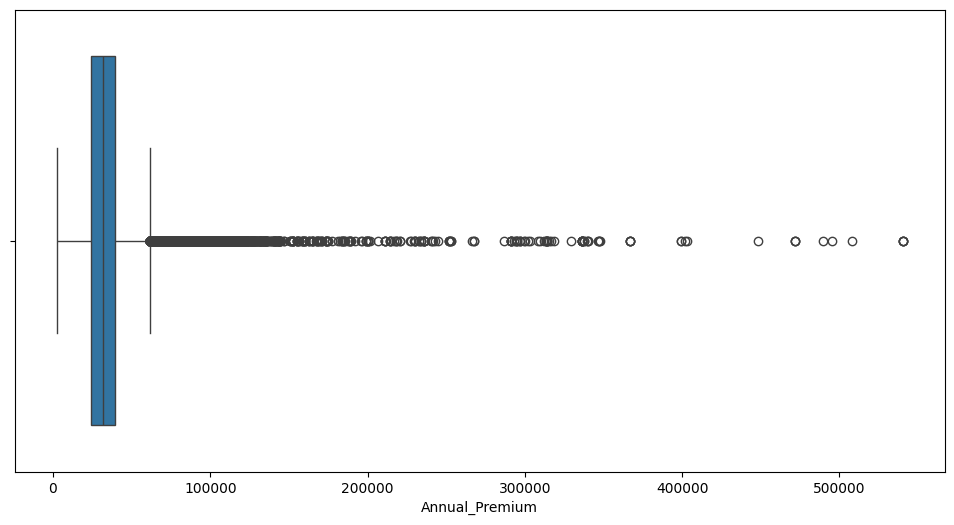

In [6]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='Annual_Premium',data=data)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


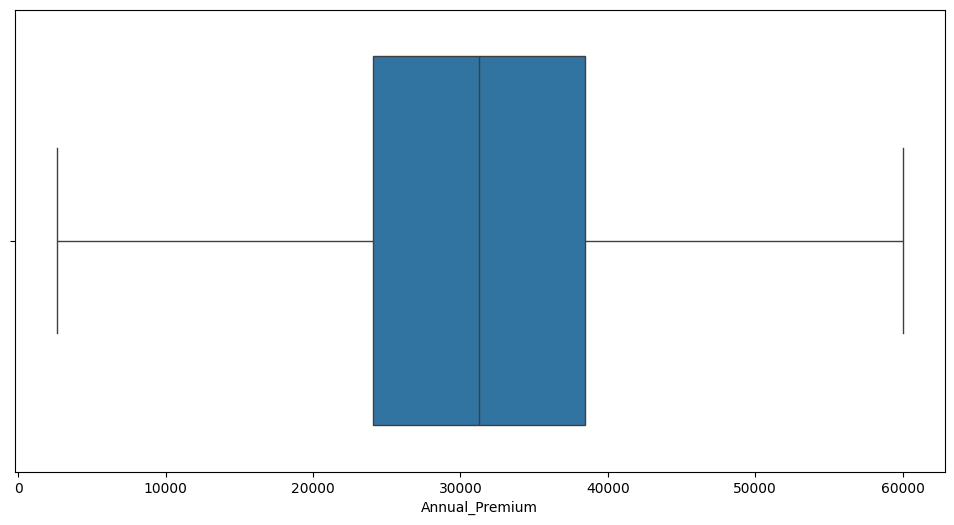

In [13]:
plt.figure(figsize=(12, 6))
data1=data[data['Annual_Premium'] < 60000]
sns.boxplot(x='Annual_Premium',data=data1)
data1.head()


In [20]:
pd.crosstab(data['Previously_Insured'], data['Response'],normalize='index')*100


Response,0,1
Previously_Insured,,
0,77.454584,22.545416
1,99.909522,0.090478


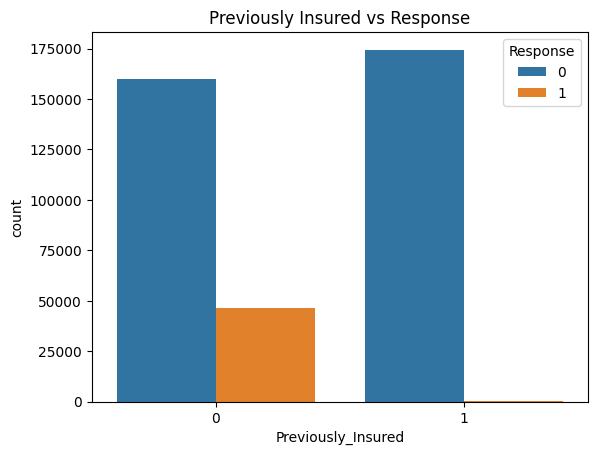

In [24]:
sns.countplot(x='Previously_Insured', hue='Response', data=data)
plt.title("Previously Insured vs Response")
plt.show()

In [27]:
pd.crosstab(data['Vehicle_Age'], data['Response'], normalize='index') * 100


Response,0,1
Vehicle_Age,,
1-2 Year,82.624453,17.375547
< 1 Year,95.629483,4.370517
> 2 Years,70.625351,29.374649


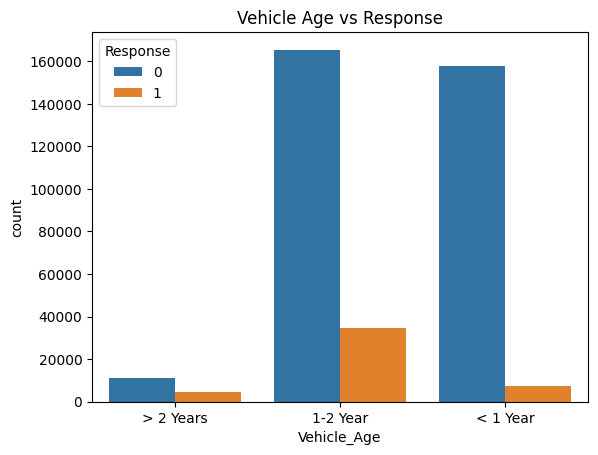

In [25]:
sns.countplot(x='Vehicle_Age', hue='Response', data=data)
plt.title("Vehicle Age vs Response")
plt.show()

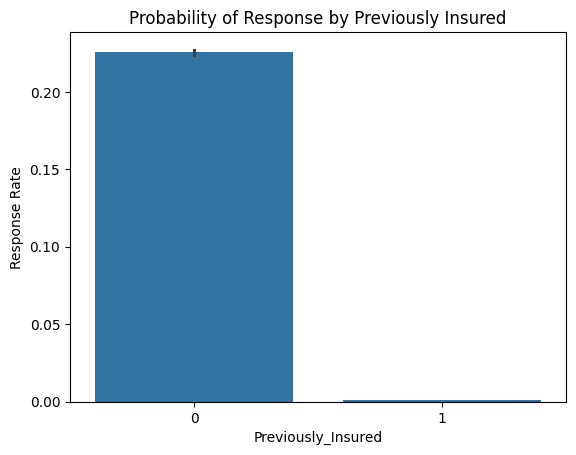

In [26]:
sns.barplot(
    x='Previously_Insured',
    y='Response',
    data=data
)
plt.title("Probability of Response by Previously Insured")
plt.ylabel("Response Rate")
plt.show()

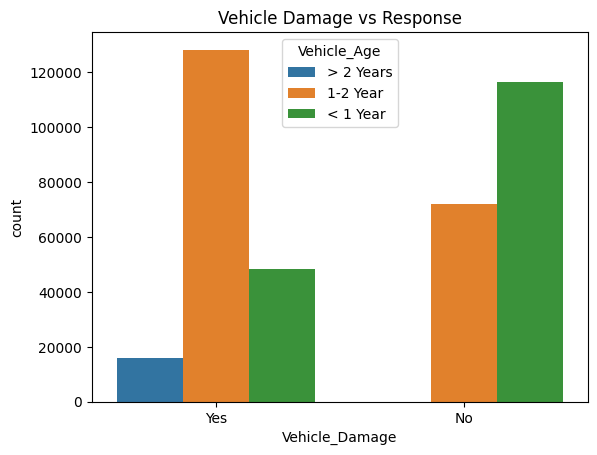

In [29]:
sns.countplot(x='Vehicle_Damage', hue='Vehicle_Age', data=data)
plt.title("Vehicle Damage vs Response")
plt.show()

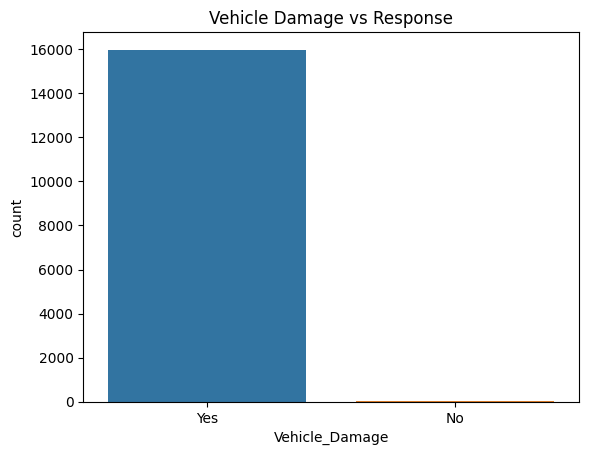

In [31]:
data_VehicleAge_2 = data[data['Vehicle_Age'] == '> 2 Years']
sns.countplot(x='Vehicle_Damage', hue='Vehicle_Damage', data=data_VehicleAge_2)
plt.title("Vehicle Damage vs Response")
plt.show()

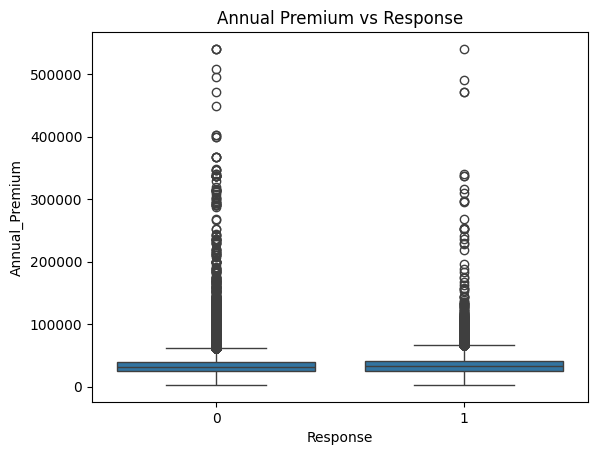

In [34]:
sns.boxplot(x='Response', y='Annual_Premium', data=data)
plt.title("Annual Premium vs Response")
plt.show()

In [36]:
data.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='str')

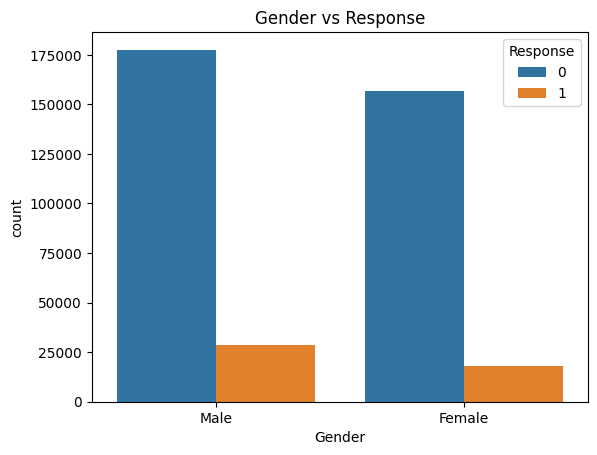

In [38]:
sns.countplot(x='Gender', hue='Response', data=data)
plt.title("Gender vs Response")
plt.show()

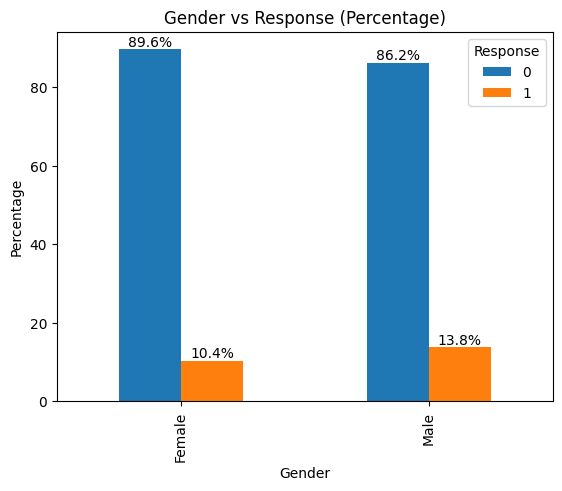

In [45]:
ct = pd.crosstab(
    data['Gender'],
    data['Response'],
    normalize='index'
)*100

ax = ct.plot(kind='bar')
plt.ylabel("Percentage")
plt.title("Gender vs Response (Percentage)")
# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()


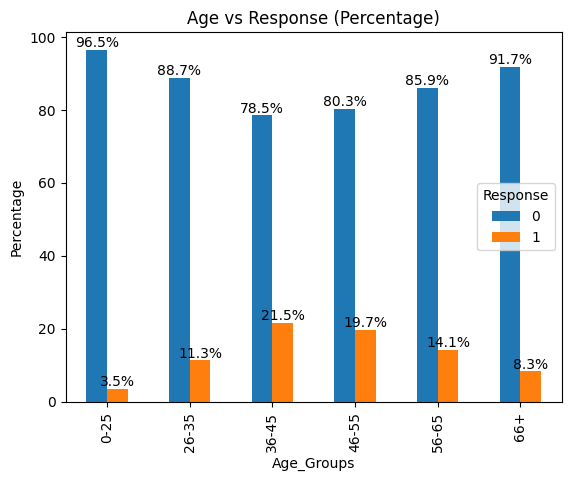

In [54]:
data['Age'].nunique()
data['Age_Groups'] = pd.cut(data['Age'], bins=[0, 25, 35, 45, 55, 65, 100], labels=['0-25', '26-35', '36-45', '46-55', '56-65', '66+'])
ct = pd.crosstab(data['Age_Groups'], data['Response'], normalize='index')*100
ax = ct.plot(kind='bar')
plt.ylabel("Percentage")
plt.title("Age vs Response (Percentage)")
# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

In [56]:
pd.crosstab(data['Driving_License'], data['Response'], normalize='index')*100

Response,0,1
Driving_License,,
0,94.950739,5.049261
1,87.728276,12.271724


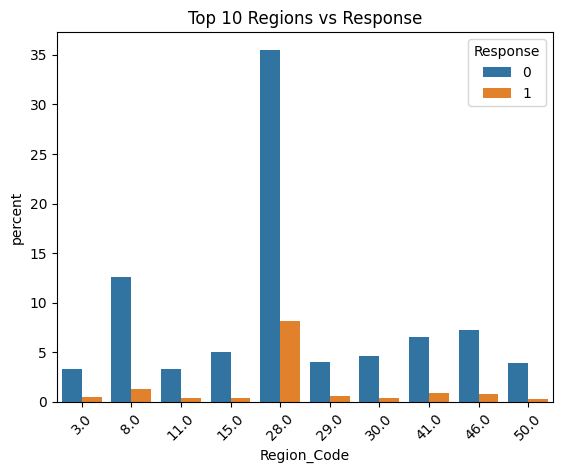

In [64]:
top_regions = data['Region_Code'].value_counts().head(10).index

filtered = data[data['Region_Code'].isin(top_regions)]

sns.countplot(x='Region_Code',data=filtered,stat='percent', hue='Response')
plt.title("Top 10 Regions vs Response")
plt.xticks(rotation=45)
plt.show()

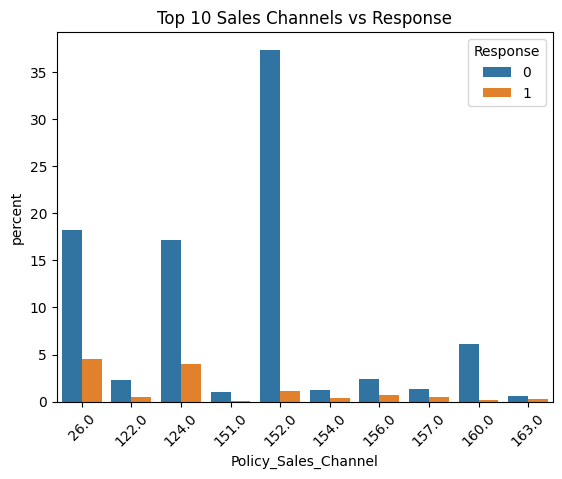

In [68]:
top_channel = data['Policy_Sales_Channel'].value_counts().head(10).index
data['Policy_Sales_Channel'].nunique()
filtered = data[data['Policy_Sales_Channel'].isin(top_channel)]

sns.countplot(x='Policy_Sales_Channel',data=filtered,stat='percent', hue='Response')
plt.title("Top 10 Sales Channels vs Response")
plt.xticks(rotation=45)
plt.show()

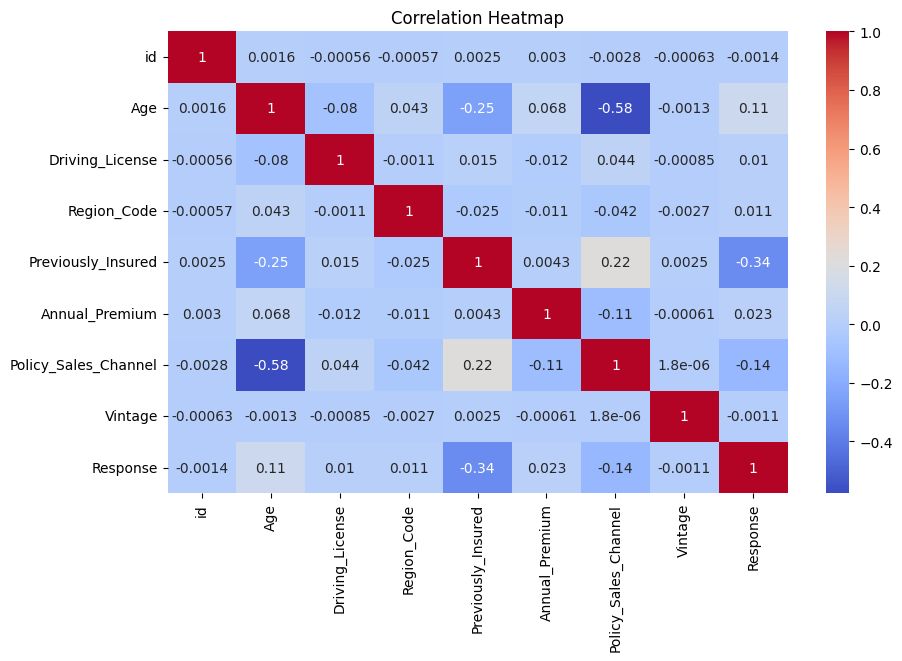

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [72]:
data['Policy_Sales_Channel'].nunique()

155

In [77]:
pd.crosstab(data['Age_Groups'], data['Policy_Sales_Channel'], normalize='index') * 100

Policy_Sales_Channel,1.0,2.0,3.0,4.0,6.0,7.0,8.0,9.0,10.0,11.0,...,152.0,153.0,154.0,155.0,156.0,157.0,158.0,159.0,160.0,163.0
Age_Groups,,,,,,,,,,,,,,,,,,,,,
0-25,0.076853,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000873,0.000873,...,73.261430,0.319637,0.472468,0.057639,1.166761,0.425309,0.072486,0.038426,15.860443,0.568534
26-35,0.492345,0.000000,0.008298,0.042873,0.002766,0.088511,0.150746,0.002766,0.001383,0.081597,...,60.649730,0.264151,2.486620,0.452238,4.902707,2.565450,0.164576,0.009681,3.638652,1.052457
36-45,0.412579,0.001418,0.107753,0.252368,0.000000,0.601146,0.586968,0.056712,0.077979,0.423921,...,5.474111,0.029774,2.777463,0.572790,4.171156,2.897975,0.130437,0.000000,0.714569,1.056258
46-55,0.316821,0.003249,0.227461,0.318445,0.001625,0.649889,0.562154,0.081236,0.173845,0.515037,...,2.596305,0.022746,1.571106,0.376935,2.573559,2.061772,0.121854,0.000000,0.409430,0.781491
56-65,0.292851,0.002929,0.453920,0.228424,0.000000,0.904911,0.817056,0.108355,0.125926,0.787771,...,3.288722,0.023428,1.323689,0.374850,2.354526,1.950391,0.199139,0.000000,0.427563,0.544704
66+,0.156757,0.000000,0.520147,0.092629,0.000000,1.428622,1.307492,0.142506,0.203071,0.919163,...,1.638819,0.024939,0.983291,0.274324,1.603192,1.293242,0.195946,0.000000,0.302825,0.245823


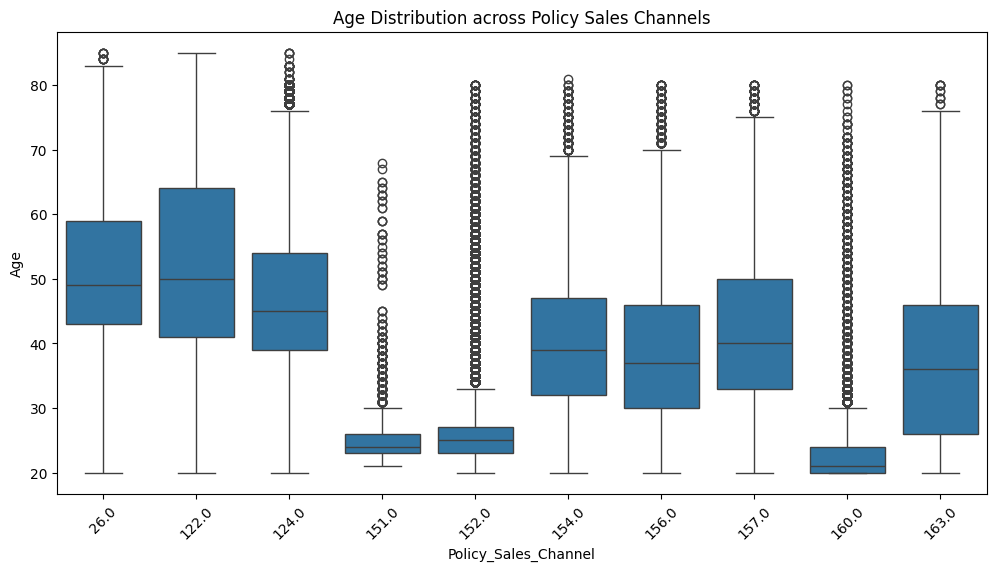

In [78]:
top_channels = data['Policy_Sales_Channel'].value_counts().head(10).index

filtered = data[data['Policy_Sales_Channel'].isin(top_channels)]

plt.figure(figsize=(12,6))
sns.boxplot(x='Policy_Sales_Channel', y='Age', data=filtered)
plt.xticks(rotation=45)
plt.title("Age Distribution across Policy Sales Channels")
plt.show()